# Homework 07 - Outliers and Risk Assumptions

This notebook detects and handles outliers, compares results with and without outliers, and reflects on the assumptions behind the chosen methods.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Setup

This setup cell creates the raw CSV used for the assignment and saves it under `data/raw/`.

In [4]:
HOMEWORK_ROOT = Path.cwd().parent
DATA_RAW = HOMEWORK_ROOT / "data" / "raw"

DATA_RAW.mkdir(parents=True, exist_ok=True)

np.random.seed(42)

n = 120
income = np.random.normal(loc=65000, scale=15000, size=n)
loan_amount = 0.32 * income + np.random.normal(loc=0, scale=5000, size=n)

income[[5, 28, 64]] = [145000, 160000, 180000]
loan_amount[[5, 28, 64]] = [85000, 95000, 120000]

df = pd.DataFrame({
    "applicant_id": range(1001, 1001 + n),
    "income": income.round(2),
    "loan_amount": loan_amount.round(2),
})

raw_path = DATA_RAW / "loan_outlier_sample.csv"
df.to_csv(raw_path, index=False)

print("Saved raw dataset to:", raw_path)
print("Shape:", df.shape)

df.head()

Saved raw dataset to: /Users/devampatel/Documents/NYU/homework/homework07/data/raw/loan_outlier_sample.csv
Shape: (120, 3)


,applicant_id,income,loan_amount
0,1001,72450.71,27139.39
1,1002,62926.04,15589.39
2,1003,74715.33,30922.88
3,1004,87845.45,21101.29
4,1005,61487.70,22610.35


## Outlier Detection Functions

This section defines reusable functions for detecting outliers with the IQR rule and Z-score rule. It also includes a winsorizing function to cap extreme values.

In [5]:
def detect_outliers_iqr(series, k=1.5):
    """Return a boolean mask for values outside the IQR outlier bounds."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr

    return (series < lower_bound) | (series > upper_bound)


def detect_outliers_zscore(series, threshold=3.0):
    """Return a boolean mask for values with absolute Z-score above the threshold."""
    mean_value = series.mean()
    std_value = series.std()

    if std_value == 0:
        return pd.Series(False, index=series.index)

    z_scores = (series - mean_value) / std_value

    return z_scores.abs() > threshold


def winsorize_series(series, lower=0.05, upper=0.95):
    """Cap values below and above selected quantiles."""
    lower_value = series.quantile(lower)
    upper_value = series.quantile(upper)

    return series.clip(lower=lower_value, upper=upper_value)

## Apply Outlier Flags

I use `loan_amount` for outlier detection because unusually large loan amounts can affect summary statistics and simple model results.

In [6]:
df["loan_amount_outlier_iqr"] = detect_outliers_iqr(df["loan_amount"], k=1.5)
df["loan_amount_outlier_zscore"] = detect_outliers_zscore(df["loan_amount"], threshold=3.0)

print("IQR outliers:", df["loan_amount_outlier_iqr"].sum())
print("Z-score outliers:", df["loan_amount_outlier_zscore"].sum())

df.loc[df["loan_amount_outlier_iqr"], ["applicant_id", "income", "loan_amount"]]

IQR outliers: 5
Z-score outliers: 3


,applicant_id,income,loan_amount
5,1006,145000.00,85000.00
28,1029,160000.00,95000.00
59,1060,79633.18,39083.46
64,1065,180000.00,120000.00
89,1090,72699.01,42527.34


## Outlier Treatments

This section creates three versions of the data: all rows, rows filtered using the IQR flag, and a winsorized version where extreme loan amounts are capped.

In [7]:
df_all = df.copy()

df_filtered = df.loc[~df["loan_amount_outlier_iqr"]].copy()

df_winsorized = df.copy()
df_winsorized["loan_amount"] = winsorize_series(df_winsorized["loan_amount"], lower=0.05, upper=0.95)

print("All rows:", len(df_all))
print("Filtered rows:", len(df_filtered))
print("Winsorized rows:", len(df_winsorized))

All rows: 120
Filtered rows: 115
Winsorized rows: 120


## Sensitivity Analysis - Summary Statistics

This section compares mean, median, and standard deviation for `loan_amount` across the original, filtered, and winsorized datasets.

In [8]:
def summarize_loan_amount(name, dataframe):
    """Return summary statistics for loan_amount in one dataset version."""
    return {
        "version": name,
        "rows": len(dataframe),
        "mean": dataframe["loan_amount"].mean(),
        "median": dataframe["loan_amount"].median(),
        "std": dataframe["loan_amount"].std(),
    }


summary_comparison = pd.DataFrame([
    summarize_loan_amount("all_rows", df_all),
    summarize_loan_amount("filtered_iqr", df_filtered),
    summarize_loan_amount("winsorized", df_winsorized),
])

summary_comparison

,version,rows,mean,median,std
0,all_rows,120,22668.994250,20976.845,14455.670544
1,filtered_iqr,115,20336.247913,20868.970,6614.156026
2,winsorized,120,20922.401433,20976.845,6843.732352


## Visual Comparison

The plots below show the loan amount distribution before and after handling outliers.

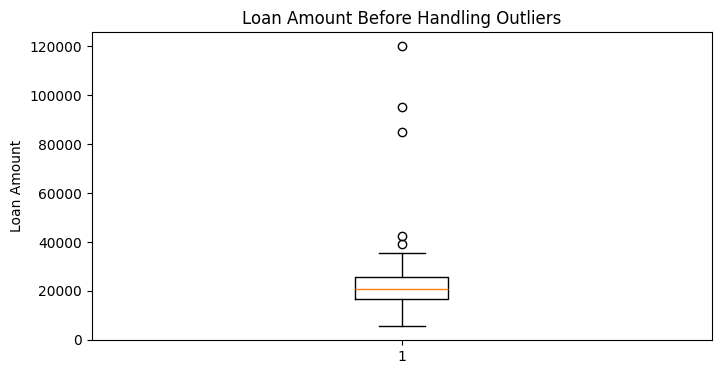

In [9]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_all["loan_amount"])
plt.title("Loan Amount Before Handling Outliers")
plt.ylabel("Loan Amount")
plt.show()

/var/folders/sj/t8jgpm5d6yjd3zzgtbmzq74m0000gn/T/ipykernel_6885/3130006549.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


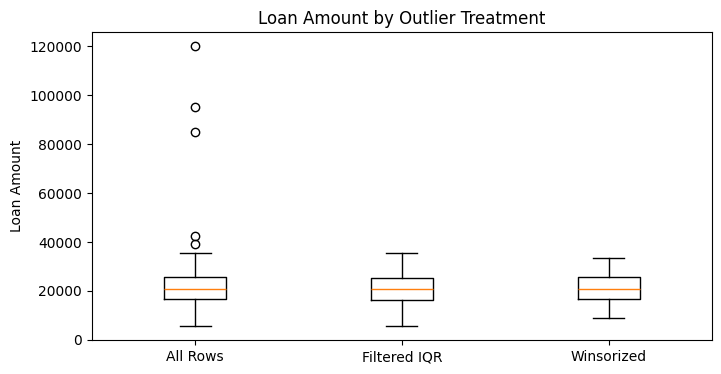

In [10]:
plt.figure(figsize=(8, 4))
plt.boxplot(
    [
        df_all["loan_amount"],
        df_filtered["loan_amount"],
        df_winsorized["loan_amount"],
    ],
    labels=["All Rows", "Filtered IQR", "Winsorized"]
)
plt.title("Loan Amount by Outlier Treatment")
plt.ylabel("Loan Amount")
plt.show()

## Sensitivity Analysis - Simple Regression

This section fits a simple regression model predicting `loan_amount` from `income` and compares the model results across the three outlier treatments.

In [11]:
def fit_simple_regression(dataframe):
    """Fit a simple linear regression and return slope, intercept, R-squared, and MAE."""
    x = dataframe["income"].to_numpy()
    y = dataframe["loan_amount"].to_numpy()

    slope, intercept = np.polyfit(x, y, deg=1)
    predictions = slope * x + intercept

    residuals = y - predictions
    mae = np.mean(np.abs(residuals))

    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    return {
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_squared,
        "mae": mae,
    }


model_comparison = pd.DataFrame([
    {"version": "all_rows", **fit_simple_regression(df_all)},
    {"version": "filtered_iqr", **fit_simple_regression(df_filtered)},
    {"version": "winsorized", **fit_simple_regression(df_winsorized)},
])

model_comparison

,version,slope,intercept,r_squared,mae
0,all_rows,0.613300,-17951.069363,0.776266,5223.660135
1,filtered_iqr,0.342239,-1419.757032,0.524756,3809.648673
2,winsorized,0.222633,6177.010046,0.456386,4122.968325


## Reflection

I used the IQR method with `k=1.5` as the main outlier rule because it works well for skewed data and does not require the column to be normally distributed. I also tested the Z-score method with a threshold of `3.0`, but that method depends more on the mean and standard deviation, which can be affected by the same extreme values we are trying to detect.

The main assumption is that unusually large loan amounts may distort the analysis. This matters because a few very large values can increase the mean and standard deviation, even when the median is more stable. In this dataset, comparing all rows, filtered rows, and winsorized rows shows how much the results change when outliers are removed or capped.

The filtered version removes rows flagged by the IQR method, while the winsorized version keeps all rows but limits extreme values. Filtering is simple, but it can remove valid observations. Winsorizing keeps the full dataset, but it changes the original values. If the outliers are real high-value loan applications, removing or capping them could hide an important part of the business problem. If they are errors or unusual cases that should not drive the analysis, keeping them could make the summary statistics and model results misleading.

Because of this, I would not automatically remove outliers without documenting the rule and checking the impact. I would compare results across multiple treatments and explain which choice best matches the context of the data.